In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import hces
df = hces.load()

df['num_hhmem_publicedu'] = pd.read_parquet('../../hces-2023-24/data/sec-4.2-CSQ.parquet').loc[df.index, 'num_hhmem_publicedu']
df['total_food'] = df[hces.FOOD_COLS].fillna(0).sum(axis=1)
df['food_pc'] = df['total_food'] / df['family_size']

for k in hces.FOOD_COLS:
    df[f"{k}_pc"] = df[k].fillna(0) / df['family_size']

df['meat_frac_pc'] = df['meat_pc'] / df['food_pc']
df['cereal_frac_pc'] = df['cereals_pc'] / df['food_pc']

In [26]:
DATA = []

## PDS
* Eligibility: everyone
* Treatment: has benefited from PMGKY or used ration card

In [27]:
xdf = df.copy()
xdf['treat'] = (xdf['has_benefited_from_pmgky'] == 'yes') | (xdf['used_ration_card'] == 'yes')
pds_abs = hces.compare(xdf, ['treat'], ["meat_pc", "cereals_pc"])
pds_pc = hces.compare(xdf, ['treat'], ["meat_frac_pc", "cereal_frac_pc"])
DATA.append({'scheme': 'PDS', 'meat_abs': pds_abs['meat_pc'], 'meat_pc': pds_pc['meat_frac_pc'], 'cereal_abs': pds_abs['cereals_pc'], 'cereal_pc': pds_pc['cereal_frac_pc']})
DATA[-1]

{'scheme': 'PDS',
 'meat_abs': treat
 False    190.615232
 True     252.237753
 Name: meat_pc, dtype: float64,
 'meat_pc': treat
 False    0.060194
 True     0.109728
 Name: meat_frac_pc, dtype: float64,
 'cereal_abs': treat
 False    301.774686
 True     213.950206
 Name: cereals_pc, dtype: float64,
 'cereal_pc': treat
 False    0.114927
 True     0.107894
 Name: cereal_frac_pc, dtype: float64}

## Health insurance
* Eligibility: households where nobody was hospitalized
* Treatment: whether someone is a beneficiary

In [28]:
xdf = df[df['is_hospitalization'] == 4].copy()
xdf['treat'] = xdf['is_hhmem_pmjay'] == 1

pds_abs = hces.compare(xdf, ['treat'], ["meat_pc", "cereals_pc"])
pds_pc = hces.compare(xdf, ['treat'], ["meat_frac_pc", "cereal_frac_pc"])
DATA.append({'scheme': 'Health Insurance', 'meat_abs': pds_abs['meat_pc'], 'meat_pc': pds_pc['meat_frac_pc'], 'cereal_abs': pds_abs['cereals_pc'], 'cereal_pc': pds_pc['cereal_frac_pc']})


## Midday Meals

* Eligibility: household has a child enrolled in a public school
* Treatment: Received midday meals

In [29]:
xdf = df[(df['num_hhmem_publicedu'] > 0) & (df['n_children'] > 0)].copy()  # Basically just eliminates higher secondary or college students
xdf['treat'] = xdf['n_school_meals'] > 0

pds_abs = hces.compare(xdf, ['treat'], ["meat_pc", "cereals_pc"])
pds_pc = hces.compare(xdf, ['treat'], ["meat_frac_pc", "cereal_frac_pc"])
DATA.append({'scheme': 'Midday Meals', 'meat_abs': pds_abs['meat_pc'], 'meat_pc': pds_pc['meat_frac_pc'], 'cereal_abs': pds_abs['cereals_pc'], 'cereal_pc': pds_pc['cereal_frac_pc']})


## LPG Subsidy
* Eligibility: Households that have LPG
* Treatment: Whether they received subsidy

In [30]:
xdf = df[df['energy_source_cooking'] == 'LPG'].copy()
xdf['treat'] = xdf['received_subsidy_lpg'] == 1

pds_abs = hces.compare(xdf, ['treat'], ["meat_pc", "cereals_pc"])
pds_pc = hces.compare(xdf, ['treat'], ["meat_frac_pc", "cereal_frac_pc"])
DATA.append({'scheme': 'LPG Subsidy', 'meat_abs': pds_abs['meat_pc'], 'meat_pc': pds_pc['meat_frac_pc'], 'cereal_abs': pds_abs['cereals_pc'], 'cereal_pc': pds_pc['cereal_frac_pc']})


## Free electricity
* Eligibility: households that use electricity
* Treatment: whether they get free electricity

In [31]:
xdf = df[df['energy_source_lighting'].str.startswith('electricity')].copy()
xdf['treat'] = xdf['received_free_electricity'] == 1

pds_abs = hces.compare(xdf, ['treat'], ["meat_pc", "cereals_pc"])
pds_pc = hces.compare(xdf, ['treat'], ["meat_frac_pc", "cereal_frac_pc"])
DATA.append({'scheme': 'Free Electricity', 'meat_abs': pds_abs['meat_pc'], 'meat_pc': pds_pc['meat_frac_pc'], 'cereal_abs': pds_abs['cereals_pc'], 'cereal_pc': pds_pc['cereal_frac_pc']})


In [32]:
meat_abs = pd.concat([k['meat_abs'] for k in DATA], axis=1)
meat_abs.columns = [k['scheme'] for k in DATA]
meat_pc =  pd.concat([k['meat_pc'] for k in DATA], axis=1)
meat_pc.columns = [k['scheme'] for k in DATA]

cereal_abs = pd.concat([k['cereal_abs'] for k in DATA], axis=1)
cereal_abs.columns = [k['scheme'] for k in DATA]
cereal_pc =  pd.concat([k['cereal_pc'] for k in DATA], axis=1)
cereal_pc.columns = [k['scheme'] for k in DATA]

In [37]:
d = meat_abs.loc[True] - meat_abs.loc[False]
order = d.sort_values().index

In [52]:
meat_abs = meat_abs[order]
meat_pc = meat_pc[order]

Text(0.5, 0.01, 'Beneficiaries of almost every major welfare measure spend more per-capita on animal protein than non-beneficiaries.\nThey also allocate to it higher fractions of the food budget.')

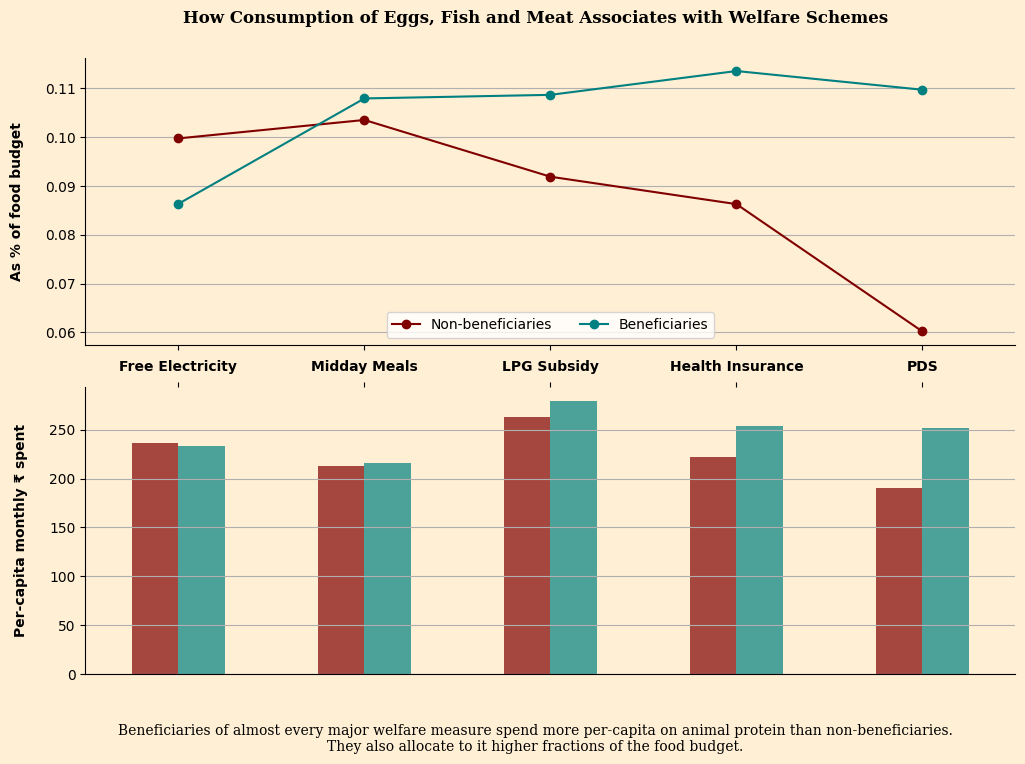

In [60]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True)
ax_abs, ax_pc = ax[::-1]

colors = ['maroon', 'teal']

meat_abs.T.plot.bar(ax=ax_abs, color=colors, alpha=0.7, rot=0)
meat_pc.T.plot(marker='o', linestyle="-", ax=ax_pc, color=colors)

# Adjust vertical spacing
ax_pc.figure.subplots_adjust(hspace=0.15)

# Remove bottom ticks/labels on both axes
ax_pc.tick_params(axis='x', bottom=True, labelbottom=False)
ax_abs.tick_params(axis='x',
                   top=True, bottom=False,
                   labeltop=True,
                   pad=6, labelbottom=False)
ax_abs.legend().remove()

handles, labels = ax_pc.get_legend_handles_labels()

label_map = {
    "False": "Non-beneficiaries",
    "True": "Beneficiaries"
}

new_labels = [label_map.get(l, l) for l in labels]
[a.grid(axis='y') for a in ax]
_ = ax_pc.legend(handles, new_labels, loc="lower center", ncol=2, title=None)

fig.set_facecolor('papayawhip')
[a.set_facecolor('papayawhip') for a in ax]

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)
ax_pc.set_ylabel('As % of food budget', fontweight="bold", fontsize=10, labelpad=15)
ax_abs.set_ylabel('Per-capita monthly ₹ spent', fontweight="bold", fontsize=10, labelpad=15)

fig.suptitle('How Consumption of Eggs, Fish and Meat Associates with Welfare Schemes', y=0.94, fontweight="bold", fontfamily="DejaVu Serif")
for label in ax_abs.get_xticklabels():
    label.set_fontweight('bold')
fig.text(0.5, 0.01,                # x=center, y=near bottom
    "Beneficiaries of almost every major welfare measure spend more per-capita on animal protein than non-beneficiaries.\nThey also allocate to it higher fractions of the food budget.",
    ha='center',
    va='bottom', fontfamily="DejaVu Serif"
)